<a href="https://colab.research.google.com/github/Peihan-Cui/CS175-AI-vs-Human-Code-Detection/blob/main/Advanced_Approach_Gemma_Qwen_Llama_Base_CS175.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Install `bitsandbytes`, needed to load the models with quantized weights

In [2]:
!pip install -U bitsandbytes>=0.46.1 # Only run ONCE and restart runtime after this finishes running

## Load the Python code examples from the HuggingFace dataset

In [1]:
from huggingface_hub import hf_hub_download

file_path = hf_hub_download(
    repo_id="OSS-forge/HumanVsAICode",
    filename="python_dataset.jsonl",
    repo_type="dataset"
)

print("File downloaded to:", file_path)

python_dataset.jsonl:   0%|          | 0.00/652M [00:00<?, ?B/s]

File downloaded to: /root/.cache/huggingface/hub/datasets--OSS-forge--HumanVsAICode/snapshots/03cac5dd2096c8901cb7a74e2ecbd26624ada497/python_dataset.jsonl


In [2]:
import json

data = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

In [3]:
import pandas as pd

python_df = pd.DataFrame(data)

code_cols = ['human_code', 'chatgpt_code', 'dsc_code', 'qwen_code']
python_df = python_df.melt(id_vars=['docstring'], value_vars=code_cols,
                  var_name='writer_type', value_name='code')

python_df['writer'] = python_df['writer_type'].map({
    'human_code': 'human',
    'chatgpt_code': 'gpt',
    'dsc_code': 'dsc',
    'qwen_code': 'qwen'
})
python_df['is_ai'] = (python_df['writer'] != 'human').astype(int)

python_df = python_df[['docstring', 'code', 'writer', 'is_ai']]

In [4]:
python_df.head()

,docstring,code,writer,is_ai
0,Sets the values to be returned after the actio...,def action_set(values):\n cmd = ['action-se...,human,0
1,Return text for index entry based on object type.,"def get_index_text(self, modname, name_cls):\n...",human,0
2,"Parse a slice string, of the same form as used...","def parse(v):\n parts = v.split(',')\n ...",human,0
3,Newton power flow routine\n\n Returns\n...,def newton(self):\n dae = self.system.d...,human,0
4,Filter the feed based on self.buffer_distance_...,def _filter_spatially(self):\n if self....,human,0


In [5]:
python_df.shape

(1140996, 4)

## Create a `sample_df` of 1000 samples with an even split between human (50%) and each AI model (50/3% each)

In [6]:
sample_df = (
    python_df
    .groupby("writer", group_keys=False)
    .apply(lambda x: x.sample(
        frac=0.50 if x.name == "human" else (0.5 / 3),
        random_state=42
    ))
    .sample(n=1000, random_state=1)
    .reset_index(drop=True)
)

/tmp/ipykernel_10660/2326805583.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [7]:
sample_df.head(12)

,docstring,code,writer,is_ai
0,Gradients with respect to x of the moments (me...,"def gradients_of_gp_moments(model, x):\n me...",gpt,1
1,Return a new 'main' module object for user cod...,"def new_main_mod(self,ns=None):\n main_...",human,0
2,Takes a list of EmailAddress instances and cle...,def clean_email_address_list(email_list):\n ...,gpt,1
3,Returns a copy of manifest with added contract...,"def contract_type(\n name: str,\n compil...",human,0
4,key_chain is an array of keys giving the path ...,"def delete_node(self, key_chain):\n nod...",human,0
5,Internal finder for local maxima .\n Return...,"def local_maxima(vector,min_distance = 4, brd_...",human,0
6,Optimise value of x using gradient descent,"def optimise_gradient_descent(x, a, c, toleran...",qwen,1
7,Disassemble instructions from the address spac...,"def disassemble(self, lpAddress, dwSize):\n ...",qwen,1
8,Takes input and returns tuple of the input in ...,"def _canonize_content_input(self, dataset, sin...",human,0
9,Creates and returns the argparse parser object.,import argparse\n\ndef create_parser():\n p...,gpt,1


Ensuring roughly even splits between the `writer` values:

In [8]:
sample_df['writer'].value_counts()

,count
writer,
human,483
qwen,183
dsc,175
gpt,159


## Define the prompts

### Few-shot prompt with 3 AI and 3 Human code examples

In [9]:
few_shot_prompt = """
You are classifying Python code as either Human-Written or AI-Generated.

Use the examples below to learn stylistic patterns. Focus on *how* the code is written, not what it does.

Weigh multiple signals (ex. number of comments, docstrings, variable nomenclature, formatting). No single feature is decisive.

Do NOT explain your reasoning, but make sure to think before giving your answer.

Human-Written example 1 (writing nested helper functions, no comments, long code length):
def _build_url(cls, request, path=None, **changes):
        changes = {k: v for k, v in changes.items() if v is not None}
        queries = {**request.url.query, **changes}
        queries = {k: v for k, v in queries.items() if v is not False}
        query_strings = []
        def add_query(key):
            query_strings.append('{}={}'.format(key, queries[key])
                                 if queries[key] != '' else key)
        def del_query(key):
            queries.pop(key, None)
        if 'head' in queries:
            add_query('head')
            del_query('head')
        if 'start' in changes:
            add_query('start')
        elif 'start' in queries:
            add_query('start')
        del_query('start')
        if 'limit' in queries:
            add_query('limit')
            del_query('limit')
        for key in sorted(queries):
            add_query(key)
        scheme = cls._get_forwarded(request, 'proto') or request.url.scheme
        host = cls._get_forwarded(request, 'host') or request.host
        forwarded_path = cls._get_forwarded(request, 'path')
        path = path if path is not None else request.path
        query = '?' + '&'.join(query_strings) if query_strings else ''
        url = '{}://{}{}{}{}'.format(scheme, host, forwarded_path, path, query)
        return url

AI-Generated example 1 (more comments, shorter code length, using imported libraries instead of helpers):
from urllib.parse import urlencode, urlparse, urlunparse
def _build_url(cls, request, path=None, **changes):
      # Parse the original URL
      parsed_url = urlparse(request.url)
        # Get the original queries
        original_queries = dict(qc.split(\"=\") for qc in parsed_url.query.split(\"&\")

        # Update the original queries with the changes
          for key, value in changes.items():
              if value is False:
                # Remove the key if it exists
                original_queries.pop(key, None)
              elif value is not None:
                # Update the key with the new value
                original_queries[key] = value
                # Build the new URL
                new_url = urlunparse((
                  parsed_url.scheme,
                  parsed_url.netloc,
                  path or parsed_url.path,
                  \"\",  # This should be empty for the queries
                  urlencode(original_queries, doseq=True),  # Encode the queries\
                  \"\"  # Fragment is not used
                ))

      return new_url

Human-Written example 2 (using custom helper function instead of built-in isinstance):
def check(self, var):
        if self._class is None: self._init()
        return self._class and self._checker(var, self._class)

AI-Generated example 2 (no comments, short code):
def check(self, var):
    raise NotImplementedError('This method should be overridden by subclasses.')

Human-Written example 3 (comments are not in Title case, they sound more like natural language):
def fullName(self):
        # join with '_' if both are set (cannot put '.', because it is used as
        # **kwargs)
        if self.parentName and self.name:
            return self.parentName + '_' + self.name
        # otherwise just use the one that is set
        # (this allows empty name for "anonymous nests")
        return self.name or self.parentName

AI-Generated example 3 (uses type annotations. Code is shorter.):
def unique_parameter_name(first_name: str, last_name: str) -> str:
    return f"{first_name} {last_name}"

Code to classify:
"""

### One-shot prompt with AI example

In [10]:
one_shot_prompt_ai = """
You are classifying Python code as either Human-Written or AI-Generated.

Use the example below to learn stylistic patterns. Focus on *how* the code is written, not what it does.

Weigh multiple signals (ex. number of comments, docstrings, variable nomenclature, formatting). No single feature is decisive.

Do NOT explain your reasoning, but make sure to think before giving your answer.

AI-Generated example (many comments and they have perfect grammar, shorter code length, using imported libraries instead of helpers):
from urllib.parse import urlencode, urlparse, urlunparse
def _build_url(cls, request, path=None, **changes):
      # Parse the original URL
      parsed_url = urlparse(request.url)
        # Get the original queries
        original_queries = dict(qc.split(\"=\") for qc in parsed_url.query.split(\"&\")

        # Update the original queries with the changes
          for key, value in changes.items():
              if value is False:
                # Remove the key if it exists
                original_queries.pop(key, None)
              elif value is not None:
                # Update the key with the new value
                original_queries[key] = value
                # Build the new URL
                new_url = urlunparse((
                  parsed_url.scheme,
                  parsed_url.netloc,
                  path or parsed_url.path,
                  \"\",  # This should be empty for the queries
                  urlencode(original_queries, doseq=True),  # Encode the queries
                  \"\"  # Fragment is not used
                ))

      return new_url

Code to classify:
"""

### One-shot prompt with Human example

In [11]:
one_shot_prompt_human = """
You are classifying Python code as either Human-Written or AI-Generated.

Use the example below to learn stylistic patterns. Focus on *how* the code is written, not what it does.

Weigh multiple signals (ex. number of comments, docstrings, variable nomenclature, formatting). No single feature is decisive.

Do NOT explain your reasoning, but make sure to think before giving your answer.

Human-Written example (writing nested helper functions, no comments, long code length):
def _build_url(cls, request, path=None, **changes):
        changes = {k: v for k, v in changes.items() if v is not None}
        queries = {**request.url.query, **changes}
        queries = {k: v for k, v in queries.items() if v is not False}
        query_strings = []
        def add_query(key):
            query_strings.append('{}={}'.format(key, queries[key])
                                 if queries[key] != '' else key)
        def del_query(key):
            queries.pop(key, None)
        if 'head' in queries:
            add_query('head')
            del_query('head')
        if 'start' in changes:
            add_query('start')
        elif 'start' in queries:
            add_query('start')
        del_query('start')
        if 'limit' in queries:
            add_query('limit')
            del_query('limit')
        for key in sorted(queries):
            add_query(key)
        scheme = cls._get_forwarded(request, 'proto') or request.url.scheme
        host = cls._get_forwarded(request, 'host') or request.host
        forwarded_path = cls._get_forwarded(request, 'path')
        path = path if path is not None else request.path
        query = '?' + '&'.join(query_strings) if query_strings else ''
        url = '{}://{}{}{}{}'.format(scheme, host, forwarded_path, path, query)
        return url

Code to classify:
"""

In [12]:
zero_shot_prompt = """
You are classifying Python code as either Human-Written or AI-Generated.
Weigh multiple signals (ex. number of comments, docstrings, variable nomenclature, formatting). No single feature is decisive.

Do NOT explain your reasoning, but make sure to think before giving your answer.

Code to classify:
"""

## Helper functions to process input and output from LLMs

### `classify_code` function to prompt the given model

In [13]:
import torch

@torch.no_grad()
def classify_code(model, tokenizer, prompt):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=4096,
    ).to(model.device)

    output_ids = model.generate(
        **inputs,
        max_new_tokens=5,
        temperature=0.0,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

    # Only decode newly generated tokens
    generated_text = tokenizer.decode(
        output_ids,
        skip_special_tokens=True,
    )
    return generated_text[0]


### Extract label from the output. Returns `INVALID` if the output is not Human/AI

In [25]:
import re

def extract_label_from_output(text: str) -> str:
    # Normalize
    text = text.strip()
    full_text = text

    # Take content after the LAST "Answer:"
    if "Answer:" in text:
        text = text.split("Answer:")[-1]

    # Remove markdown code fences
    text = re.sub(r"```+", "", text)

    # Split into lines and take first non-empty line
    for line in text.splitlines():
        line = line.strip()
        if line:
            text = line
            break
    else:
        return "INVALID"

    # Remove surrounding quotes (", ', or escaped \" \")
    text = text.strip()
    text = re.sub(r'^["\']|["\']$', "", text)          # "Human-Written"
    text = re.sub(r'^\\"|\\"$', "", text)              # \"Human-Written\"

    # Final validation
    if text in {"Human-Written", "Human-written", "human-written"}:
      return "Human-Written"
    elif text in {"AI-Generated", "AI-generated", "ai-generated"}:
      return "AI-Generated"

    print("Invalid text:", text)
    print(full_text)
    return "INVALID"

## Load Gemma3 model with 1b params

In [15]:
from transformers import AutoTokenizer, BitsAndBytesConfig, Gemma3ForCausalLM
import torch

In [16]:
gemma_model_id = "google/gemma-3-1b-it"

quantization_config = BitsAndBytesConfig(load_in_8bit=True) # Will also try load_in_4bit

gemma_model = Gemma3ForCausalLM.from_pretrained(
    gemma_model_id, quantization_config=quantization_config
).eval()

gemma_tokenizer = AutoTokenizer.from_pretrained(gemma_model_id)

config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

## Run all of the above prompts with on the Gemma model with `sample_df` and see the results

### Few-shot prompt

In [26]:
predictions = []

for idx, row in sample_df.iterrows():
    prompt = few_shot_prompt + '\n' + row["code"]
    prompt += """\nAnswer with exactly one of the following labels:
Human-Written
AI-Generated
Do NOT use markdown, code blocks, or backticks in your answer.

Answer:
"""
    pred = classify_code(gemma_model, gemma_tokenizer, prompt)
    predictions.append(pred)

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


In [29]:
final_preds = []
for p in predictions:
  final_preds.append(extract_label_from_output(p))

predictions = final_preds

Invalid text: You are classifying Python code as either Human-Written or AI-Generated.
You are classifying Python code as either Human-Written or AI-Generated.

Use the examples below to learn stylistic patterns. Focus on *how* the code is written, not what it does.

Weigh multiple signals (ex. number of comments, docstrings, variable nomenclature, formatting). No single feature is decisive.

Do NOT explain your reasoning, but make sure to think before giving your answer.

Human-Written example 1 (writing nested helper functions, no comments, long code length):
def _build_url(cls, request, path=None, **changes):
        changes = {k: v for k, v in changes.items() if v is not None}
        queries = {**request.url.query, **changes}
        queries = {k: v for k, v in queries.items() if v is not False}
        query_strings = []
        def add_query(key):
            query_strings.append('{}={}'.format(key, queries[key])
                                 if queries[key] != '' else key)
 

In [30]:
sample_df["gemma_label"] = predictions

In [31]:
sample_df.head(12)

,docstring,code,writer,is_ai,gemma_label,gemma_is_ai
0,Gradients with respect to x of the moments (me...,"def gradients_of_gp_moments(model, x):\n me...",gpt,1,AI-Generated,NaN
1,Return a new 'main' module object for user cod...,"def new_main_mod(self,ns=None):\n main_...",human,0,AI-Generated,NaN
2,Takes a list of EmailAddress instances and cle...,def clean_email_address_list(email_list):\n ...,gpt,1,AI-Generated,NaN
3,Returns a copy of manifest with added contract...,"def contract_type(\n name: str,\n compil...",human,0,AI-Generated,NaN
4,key_chain is an array of keys giving the path ...,"def delete_node(self, key_chain):\n nod...",human,0,AI-Generated,NaN
5,Internal finder for local maxima .\n Return...,"def local_maxima(vector,min_distance = 4, brd_...",human,0,AI-Generated,NaN
6,Optimise value of x using gradient descent,"def optimise_gradient_descent(x, a, c, toleran...",qwen,1,AI-Generated,NaN
7,Disassemble instructions from the address spac...,"def disassemble(self, lpAddress, dwSize):\n ...",qwen,1,AI-Generated,NaN
8,Takes input and returns tuple of the input in ...,"def _canonize_content_input(self, dataset, sin...",human,0,AI-Generated,NaN
9,Creates and returns the argparse parser object.,import argparse\n\ndef create_parser():\n p...,gpt,1,AI-Generated,NaN


In [32]:
sample_df['gemma_label'].value_counts()

,count
gemma_label,
AI-Generated,900
Human-Written,98
INVALID,2


In [33]:
sample_df["gemma_is_ai"] = sample_df["gemma_label"].map({
    "Human-Written": 0,
    "AI-Generated": 1,
})


In [34]:
sample_df.head()

,docstring,code,writer,is_ai,gemma_label,gemma_is_ai
0,Gradients with respect to x of the moments (me...,"def gradients_of_gp_moments(model, x):\n me...",gpt,1,AI-Generated,1.0
1,Return a new 'main' module object for user cod...,"def new_main_mod(self,ns=None):\n main_...",human,0,AI-Generated,1.0
2,Takes a list of EmailAddress instances and cle...,def clean_email_address_list(email_list):\n ...,gpt,1,AI-Generated,1.0
3,Returns a copy of manifest with added contract...,"def contract_type(\n name: str,\n compil...",human,0,AI-Generated,1.0
4,key_chain is an array of keys giving the path ...,"def delete_node(self, key_chain):\n nod...",human,0,AI-Generated,1.0


In [35]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

mask = sample_df["gemma_is_ai"].notna()

y_true_f = sample_df.loc[mask, "is_ai"]
y_pred_f = sample_df.loc[mask, "gemma_is_ai"]

cm = confusion_matrix(y_true_f, y_pred_f)

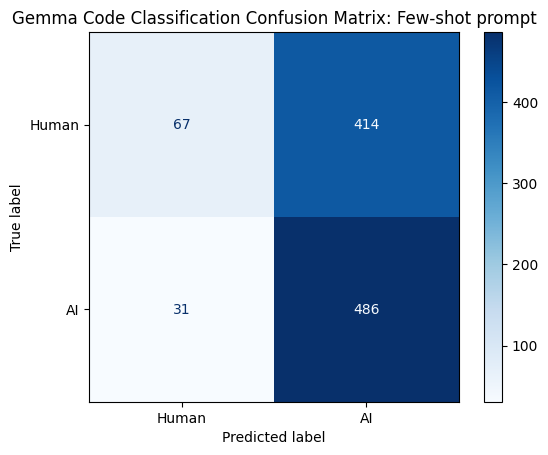

In [36]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Human", "AI"]
)

disp.plot(cmap="Blues", values_format="d")  # values_format="d" shows integers
plt.title("Gemma Code Classification Confusion Matrix: Few-shot prompt")
plt.show()

In [37]:
accuracy_score(y_true_f, y_pred_f)

0.5541082164328658

### One-shot prompt with AI example

In [38]:
predictions = []

for idx, row in sample_df.iterrows():
    prompt = one_shot_prompt_ai + '\n' + row["code"]
    prompt += """\nAnswer with exactly one of the following labels:
Human-Written
AI-Generated
Do NOT use markdown, code blocks, or backticks in your answer.

Answer:
"""
    pred = classify_code(gemma_model, gemma_tokenizer, prompt)
    predictions.append(extract_label_from_output(pred))

sample_df["gemma_label"] = predictions

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


In [39]:
sample_df.head(12)

,docstring,code,writer,is_ai,gemma_label,gemma_is_ai
0,Gradients with respect to x of the moments (me...,"def gradients_of_gp_moments(model, x):\n me...",gpt,1,Human-Written,1.0
1,Return a new 'main' module object for user cod...,"def new_main_mod(self,ns=None):\n main_...",human,0,Human-Written,1.0
2,Takes a list of EmailAddress instances and cle...,def clean_email_address_list(email_list):\n ...,gpt,1,Human-Written,1.0
3,Returns a copy of manifest with added contract...,"def contract_type(\n name: str,\n compil...",human,0,Human-Written,1.0
4,key_chain is an array of keys giving the path ...,"def delete_node(self, key_chain):\n nod...",human,0,AI-Generated,1.0
5,Internal finder for local maxima .\n Return...,"def local_maxima(vector,min_distance = 4, brd_...",human,0,Human-Written,1.0
6,Optimise value of x using gradient descent,"def optimise_gradient_descent(x, a, c, toleran...",qwen,1,Human-Written,1.0
7,Disassemble instructions from the address spac...,"def disassemble(self, lpAddress, dwSize):\n ...",qwen,1,AI-Generated,1.0
8,Takes input and returns tuple of the input in ...,"def _canonize_content_input(self, dataset, sin...",human,0,Human-Written,1.0
9,Creates and returns the argparse parser object.,import argparse\n\ndef create_parser():\n p...,gpt,1,Human-Written,1.0


In [40]:
sample_df['gemma_label'].value_counts()

,count
gemma_label,
Human-Written,697
AI-Generated,303


In [41]:
sample_df["gemma_is_ai"] = sample_df["gemma_label"].map({
    "Human-Written": 0,
    "AI-Generated": 1,
})


In [42]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

mask = sample_df["gemma_is_ai"].notna()

y_true_f = sample_df.loc[mask, "is_ai"]
y_pred_f = sample_df.loc[mask, "gemma_is_ai"]

cm = confusion_matrix(y_true_f, y_pred_f)

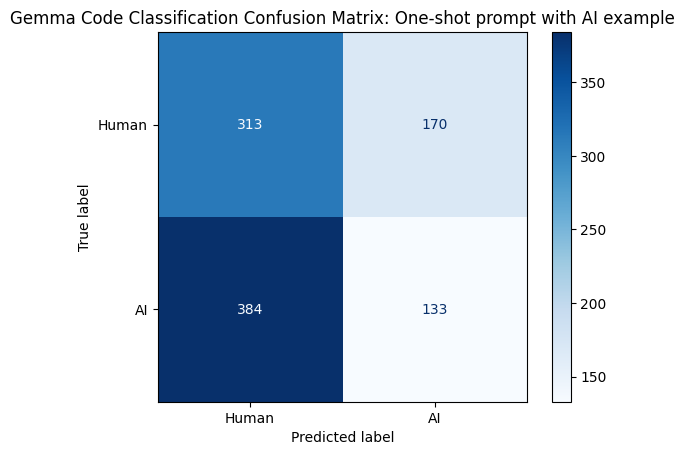

In [43]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Human", "AI"]
)

disp.plot(cmap="Blues", values_format="d")  # values_format="d" shows integers
plt.title("Gemma Code Classification Confusion Matrix: One-shot prompt with AI example")
plt.show()

In [44]:
accuracy_score(y_true_f, y_pred_f)

0.446

### One-shot prompt with human example

In [45]:
predictions = []

for idx, row in sample_df.iterrows():
    prompt = one_shot_prompt_human + '\n' + row["code"]
    prompt += """\nAnswer with exactly one of the following labels:
Human-Written
AI-Generated
Do NOT use markdown, code blocks, or backticks in your answer.

Answer:
"""
    pred = classify_code(gemma_model, gemma_tokenizer, prompt)
    predictions.append(extract_label_from_output(pred))

sample_df["gemma_label"] = predictions

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


In [46]:
sample_df.head(12)

,docstring,code,writer,is_ai,gemma_label,gemma_is_ai
0,Gradients with respect to x of the moments (me...,"def gradients_of_gp_moments(model, x):\n me...",gpt,1,Human-Written,0
1,Return a new 'main' module object for user cod...,"def new_main_mod(self,ns=None):\n main_...",human,0,AI-Generated,0
2,Takes a list of EmailAddress instances and cle...,def clean_email_address_list(email_list):\n ...,gpt,1,Human-Written,0
3,Returns a copy of manifest with added contract...,"def contract_type(\n name: str,\n compil...",human,0,Human-Written,0
4,key_chain is an array of keys giving the path ...,"def delete_node(self, key_chain):\n nod...",human,0,AI-Generated,1
5,Internal finder for local maxima .\n Return...,"def local_maxima(vector,min_distance = 4, brd_...",human,0,Human-Written,0
6,Optimise value of x using gradient descent,"def optimise_gradient_descent(x, a, c, toleran...",qwen,1,Human-Written,0
7,Disassemble instructions from the address spac...,"def disassemble(self, lpAddress, dwSize):\n ...",qwen,1,AI-Generated,1
8,Takes input and returns tuple of the input in ...,"def _canonize_content_input(self, dataset, sin...",human,0,Human-Written,0
9,Creates and returns the argparse parser object.,import argparse\n\ndef create_parser():\n p...,gpt,1,Human-Written,0


In [47]:
sample_df['gemma_label'].value_counts()

,count
gemma_label,
AI-Generated,510
Human-Written,490


In [48]:
sample_df["gemma_is_ai"] = sample_df["gemma_label"].map({
    "Human-Written": 0,
    "AI-Generated": 1,
})


In [49]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

mask = sample_df["gemma_is_ai"].notna()

y_true_f = sample_df.loc[mask, "is_ai"]
y_pred_f = sample_df.loc[mask, "gemma_is_ai"]

cm = confusion_matrix(y_true_f, y_pred_f)

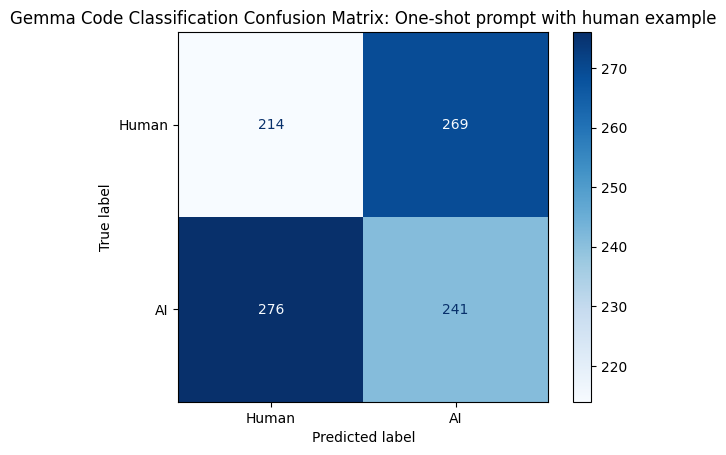

In [50]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Human", "AI"]
)

disp.plot(cmap="Blues", values_format="d")  # values_format="d" shows integers
plt.title("Gemma Code Classification Confusion Matrix: One-shot prompt with human example")
plt.show()

In [51]:
accuracy_score(y_true_f, y_pred_f)

0.455

### Zero-shot prompt

In [52]:
predictions = []

for idx, row in sample_df.iterrows():
    prompt = zero_shot_prompt + '\n' + row["code"]
    prompt += """\nAnswer with exactly one of the following labels:
Human-Written
AI-Generated
Do NOT use markdown, code blocks, or backticks in your answer.

Answer:
"""
    pred = classify_code(gemma_model, gemma_tokenizer, prompt)
    predictions.append(extract_label_from_output(pred))

sample_df["gemma_label"] = predictions

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Invalid text: Do NOT use markdown,
You are classifying Python code as either Human-Written or AI-Generated.
Weigh multiple signals (ex. number of comments, docstrings, variable nomenclature, formatting). No single feature is decisive.

Do NOT explain your reasoning, but make sure to think before giving your answer.

Code to classify:

import sqlite3

def delete(self):
    conn = sqlite3.connect('my_database.db')  # Connect to the database
    c = conn.cursor()

    c.execute("DELETE FROM my_table WHERE my_condition")  # Delete the record

    conn.commit()  # Save (commit) the changes
    conn.close()  # Close the connection

    return c.rowcount  # Return the number of rows deleted
Answer with exactly one of the following labels:
Human-Written
AI-Generated
Do NOT use markdown, code blocks, or backticks in your answer.

Answer:
Do NOT use markdown,
Invalid text: python
You are classifying Python code as either Human-Written or AI-Generated.
Weigh multiple signals (ex. number of commen

In [53]:
sample_df.head(12)

,docstring,code,writer,is_ai,gemma_label,gemma_is_ai
0,Gradients with respect to x of the moments (me...,"def gradients_of_gp_moments(model, x):\n me...",gpt,1,Human-Written,0
1,Return a new 'main' module object for user cod...,"def new_main_mod(self,ns=None):\n main_...",human,0,Human-Written,1
2,Takes a list of EmailAddress instances and cle...,def clean_email_address_list(email_list):\n ...,gpt,1,Human-Written,0
3,Returns a copy of manifest with added contract...,"def contract_type(\n name: str,\n compil...",human,0,Human-Written,0
4,key_chain is an array of keys giving the path ...,"def delete_node(self, key_chain):\n nod...",human,0,Human-Written,1
5,Internal finder for local maxima .\n Return...,"def local_maxima(vector,min_distance = 4, brd_...",human,0,Human-Written,0
6,Optimise value of x using gradient descent,"def optimise_gradient_descent(x, a, c, toleran...",qwen,1,Human-Written,0
7,Disassemble instructions from the address spac...,"def disassemble(self, lpAddress, dwSize):\n ...",qwen,1,Human-Written,1
8,Takes input and returns tuple of the input in ...,"def _canonize_content_input(self, dataset, sin...",human,0,Human-Written,0
9,Creates and returns the argparse parser object.,import argparse\n\ndef create_parser():\n p...,gpt,1,Human-Written,0


In [54]:
sample_df['gemma_label'].value_counts()

,count
gemma_label,
Human-Written,740
AI-Generated,255
INVALID,5


In [55]:
sample_df["gemma_is_ai"] = sample_df["gemma_label"].map({
    "Human-Written": 0,
    "AI-Generated": 1,
})


In [56]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

mask = sample_df["gemma_is_ai"].notna()

y_true_f = sample_df.loc[mask, "is_ai"]
y_pred_f = sample_df.loc[mask, "gemma_is_ai"]

cm = confusion_matrix(y_true_f, y_pred_f)

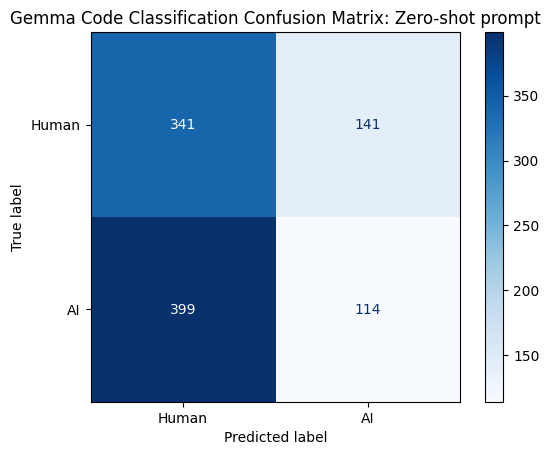

In [57]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Human", "AI"]
)

disp.plot(cmap="Blues", values_format="d")  # values_format="d" shows integers
plt.title("Gemma Code Classification Confusion Matrix: Zero-shot prompt")
plt.show()

In [58]:
accuracy_score(y_true_f, y_pred_f)

0.457286432160804

## Qwen model with 0.5B params

In [ ]:
from transformers import AutoModelForCausalLM

In [ ]:
qwen_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct")
quantization_config = BitsAndBytesConfig(load_in_8bit=True) # Will also try load_in_4bit
qwen_model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct", quantization_config=quantization_config).eval()

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

### Zero-shot prompt

In [ ]:
predictions = []

for idx, row in sample_df.iterrows():
    prompt = zero_shot_prompt + '\n' + row["code"]
    prompt += """Your output should only contain one of the following labels and NOTHING ELSE:
\"Human-Written\" OR
\"AI-Generated\"
Do NOT surround your answer with markdown, quotes, code blocks, or backticks in your answer. DON'T EXPLAIN WHAT THE CODE DOES

Answer:
"""
    pred = classify_code(qwen_model, qwen_tokenizer, prompt)
    predictions.append(extract_label_from_output(pred))

sample_df["qwen_label"] = predictions

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Invalid text: The given code snippet appears
Invalid text: The provided Python code appears
Invalid text: The provided Python code appears
Invalid text: The provided Python code appears
Invalid text: The provided code snippet does
Invalid text: The provided Python code appears
Invalid text: The provided code snippet appears
Invalid text: The code you provided appears
Invalid text: The provided code snippet appears
Invalid text: The given code snippet appears
Invalid text: The code you provided does
Invalid text: The provided Python code appears
Invalid text: The code you provided appears
Invalid text: The provided Python code appears
Invalid text: The provided Python code appears
Invalid text: The provided code snippet appears
Invalid text: The provided Python code appears
Invalid text: The provided Python code appears
Invalid text: The provided code snippet appears
Invalid text: The code you provided appears
Invalid text: The provided code snippet appears
Invalid text: The provided co

In [ ]:
sample_df.head(12)

,docstring,code,writer,is_ai,qwen_label
0,Gradients with respect to x of the moments (me...,"def gradients_of_gp_moments(model, x):\n me...",gpt,1,AI-Generated
1,Return a new 'main' module object for user cod...,"def new_main_mod(self,ns=None):\n main_...",human,0,Human-Written
2,Takes a list of EmailAddress instances and cle...,def clean_email_address_list(email_list):\n ...,gpt,1,AI-Generated
3,Returns a copy of manifest with added contract...,"def contract_type(\n name: str,\n compil...",human,0,AI-Generated
4,key_chain is an array of keys giving the path ...,"def delete_node(self, key_chain):\n nod...",human,0,AI-Generated
5,Internal finder for local maxima .\n Return...,"def local_maxima(vector,min_distance = 4, brd_...",human,0,AI-Generated
6,Optimise value of x using gradient descent,"def optimise_gradient_descent(x, a, c, toleran...",qwen,1,AI-Generated
7,Disassemble instructions from the address spac...,"def disassemble(self, lpAddress, dwSize):\n ...",qwen,1,AI-Generated
8,Takes input and returns tuple of the input in ...,"def _canonize_content_input(self, dataset, sin...",human,0,AI-Generated
9,Creates and returns the argparse parser object.,import argparse\n\ndef create_parser():\n p...,gpt,1,AI-Generated


In [ ]:
sample_df["qwen_is_ai"] = sample_df["qwen_label"].map({
    "Human-Written": 0,
    "AI-Generated": 1,
})

In [ ]:
sample_df['qwen_label'].value_counts()

,count
qwen_label,
AI-Generated,782
Human-Written,196
INVALID,22


In [ ]:
sample_df.head(12)

,docstring,code,writer,is_ai,qwen_label,qwen_is_ai
0,Gradients with respect to x of the moments (me...,"def gradients_of_gp_moments(model, x):\n me...",gpt,1,AI-Generated,1.0
1,Return a new 'main' module object for user cod...,"def new_main_mod(self,ns=None):\n main_...",human,0,Human-Written,0.0
2,Takes a list of EmailAddress instances and cle...,def clean_email_address_list(email_list):\n ...,gpt,1,AI-Generated,1.0
3,Returns a copy of manifest with added contract...,"def contract_type(\n name: str,\n compil...",human,0,AI-Generated,1.0
4,key_chain is an array of keys giving the path ...,"def delete_node(self, key_chain):\n nod...",human,0,AI-Generated,1.0
5,Internal finder for local maxima .\n Return...,"def local_maxima(vector,min_distance = 4, brd_...",human,0,AI-Generated,1.0
6,Optimise value of x using gradient descent,"def optimise_gradient_descent(x, a, c, toleran...",qwen,1,AI-Generated,1.0
7,Disassemble instructions from the address spac...,"def disassemble(self, lpAddress, dwSize):\n ...",qwen,1,AI-Generated,1.0
8,Takes input and returns tuple of the input in ...,"def _canonize_content_input(self, dataset, sin...",human,0,AI-Generated,1.0
9,Creates and returns the argparse parser object.,import argparse\n\ndef create_parser():\n p...,gpt,1,AI-Generated,1.0


In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

mask = sample_df["qwen_is_ai"].notna()

y_true_f = sample_df.loc[mask, "is_ai"]
y_pred_f = sample_df.loc[mask, "qwen_is_ai"]

cm = confusion_matrix(y_true_f, y_pred_f)

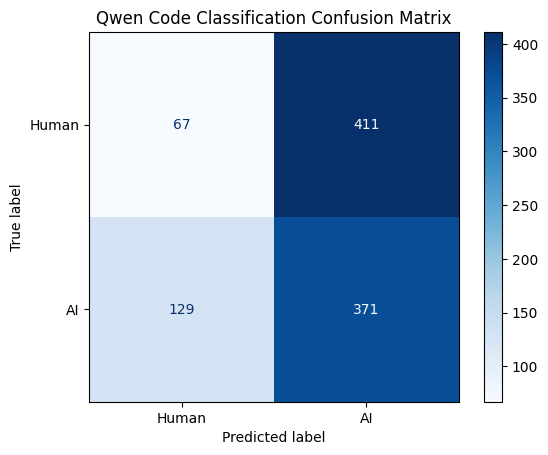

In [ ]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Human", "AI"]
)

disp.plot(cmap="Blues", values_format="d")  # values_format="d" shows integers
plt.title("Qwen Code Classification Confusion Matrix")
plt.show()

In [ ]:
accuracy_score(y_true_f, y_pred_f)

0.44785276073619634

### To see the results from the remaining prompting techniques for the Qwen model, refer to this table with confusion matrices and accuracy scores in the final report: https://docs.google.com/document/d/1XQgRs28iHyZEh8HGMXOTg7xntLy2mSInvu0sQS4imXU/edit?tab=t.0#bookmark=id.4p24k0z48vc3

## Meta Llama model with 1B params

In [ ]:
from transformers import AutoModelForCausalLM

In [ ]:
llama_tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B")
quantization_config = BitsAndBytesConfig(load_in_8bit=True) # Will also try load_in_4bit
llama_model = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-3.2-1B", quantization_config=quantization_config).eval()

config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

In [ ]:
sample_df

,docstring,code,writer,is_ai,llama_label,llama_is_ai
0,Gradients with respect to x of the moments (me...,"def gradients_of_gp_moments(model, x):\n me...",gpt,1,Human-Written,0.0
1,Return a new 'main' module object for user cod...,"def new_main_mod(self,ns=None):\n main_...",human,0,INVALID,NaN
2,Takes a list of EmailAddress instances and cle...,def clean_email_address_list(email_list):\n ...,gpt,1,Human-Written,0.0
3,Returns a copy of manifest with added contract...,"def contract_type(\n name: str,\n compil...",human,0,INVALID,NaN
4,key_chain is an array of keys giving the path ...,"def delete_node(self, key_chain):\n nod...",human,0,Human-Written,0.0
5,Internal finder for local maxima .\n Return...,"def local_maxima(vector,min_distance = 4, brd_...",human,0,INVALID,NaN
6,Optimise value of x using gradient descent,"def optimise_gradient_descent(x, a, c, toleran...",qwen,1,Human-Written,0.0
7,Disassemble instructions from the address spac...,"def disassemble(self, lpAddress, dwSize):\n ...",qwen,1,Human-Written,0.0
8,Takes input and returns tuple of the input in ...,"def _canonize_content_input(self, dataset, sin...",human,0,INVALID,NaN
9,Creates and returns the argparse parser object.,import argparse\n\ndef create_parser():\n p...,gpt,1,INVALID,NaN


### Few-shot prompt

In [ ]:
predictions = []

for idx, row in sample_df.iterrows():
    prompt = few_shot_prompt + row["code"]
    prompt += """Your output should be one of these 2 JSON strings: {\"Human-Written\": 0, \"AI-Generated\": 1} or {\"Human-Written\": 1, \"AI-Generated\": 0}
Answer:
"""
    pred = classify_code(llama_model, llama_tokenizer, prompt)
    predictions.append(extract_label_from_output(pred))

sample_df["llama_label"] = predictions

Invalid text: {"Human-Written":
You are classifying Python code as either Human-Written or AI-Generated.

Use the examples below to learn stylistic patterns. Focus on *how* the code is written, not what it does.

Weigh multiple signals (ex. number of comments, docstrings, variable nomenclature, formatting). No single feature is decisive.

Do NOT explain your reasoning, but make sure to think before giving your answer.

Human-Written example 1 (writing nested helper functions, no comments, long code length):
def _build_url(cls, request, path=None, **changes):
        changes = {k: v for k, v in changes.items() if v is not None}
        queries = {**request.url.query, **changes}
        queries = {k: v for k, v in queries.items() if v is not False}
        query_strings = []
        def add_query(key):
            query_strings.append('{}={}'.format(key, queries[key])
                                 if queries[key] != '' else key)
        def del_query(key):
            queries.pop(key,

KeyboardInterrupt: 

In [ ]:
sample_df.head(12)

,docstring,code,writer,is_ai,llama_label,llama_is_ai
0,Gradients with respect to x of the moments (me...,"def gradients_of_gp_moments(model, x):\n me...",gpt,1,Human-Written,1.0
1,Return a new 'main' module object for user cod...,"def new_main_mod(self,ns=None):\n main_...",human,0,Human-Written,0.0
2,Takes a list of EmailAddress instances and cle...,def clean_email_address_list(email_list):\n ...,gpt,1,INVALID,0.0
3,Returns a copy of manifest with added contract...,"def contract_type(\n name: str,\n compil...",human,0,INVALID,0.0
4,key_chain is an array of keys giving the path ...,"def delete_node(self, key_chain):\n nod...",human,0,INVALID,0.0
5,Internal finder for local maxima .\n Return...,"def local_maxima(vector,min_distance = 4, brd_...",human,0,INVALID,0.0
6,Optimise value of x using gradient descent,"def optimise_gradient_descent(x, a, c, toleran...",qwen,1,Human-Written,0.0
7,Disassemble instructions from the address spac...,"def disassemble(self, lpAddress, dwSize):\n ...",qwen,1,Human-Written,0.0
8,Takes input and returns tuple of the input in ...,"def _canonize_content_input(self, dataset, sin...",human,0,Human-Written,0.0
9,Creates and returns the argparse parser object.,import argparse\n\ndef create_parser():\n p...,gpt,1,INVALID,0.0


In [ ]:
sample_df["llama_is_ai"] = sample_df["llama_label"].map({
    "{\"Human-Written\": 0, \"AI-Generated\": 1}": 1,
    "{\"Human-Written\": 1, \"AI-Generated\": 0}": 0,
})

In [ ]:
sample_df.head(12)

,docstring,code,writer,is_ai,llama_label,llama_is_ai
0,Gradients with respect to x of the moments (me...,"def gradients_of_gp_moments(model, x):\n me...",gpt,1,Human-Written,0.0
1,Return a new 'main' module object for user cod...,"def new_main_mod(self,ns=None):\n main_...",human,0,Human-Written,0.0
2,Takes a list of EmailAddress instances and cle...,def clean_email_address_list(email_list):\n ...,gpt,1,INVALID,NaN
3,Returns a copy of manifest with added contract...,"def contract_type(\n name: str,\n compil...",human,0,INVALID,NaN
4,key_chain is an array of keys giving the path ...,"def delete_node(self, key_chain):\n nod...",human,0,INVALID,NaN
5,Internal finder for local maxima .\n Return...,"def local_maxima(vector,min_distance = 4, brd_...",human,0,INVALID,NaN
6,Optimise value of x using gradient descent,"def optimise_gradient_descent(x, a, c, toleran...",qwen,1,Human-Written,0.0
7,Disassemble instructions from the address spac...,"def disassemble(self, lpAddress, dwSize):\n ...",qwen,1,Human-Written,0.0
8,Takes input and returns tuple of the input in ...,"def _canonize_content_input(self, dataset, sin...",human,0,Human-Written,0.0
9,Creates and returns the argparse parser object.,import argparse\n\ndef create_parser():\n p...,gpt,1,INVALID,NaN


In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

mask = sample_df["llama_is_ai"].notna()

y_true_f = sample_df.loc[mask, "is_ai"]
y_pred_f = sample_df.loc[mask, "llama_is_ai"]

cm = confusion_matrix(y_true_f, y_pred_f)

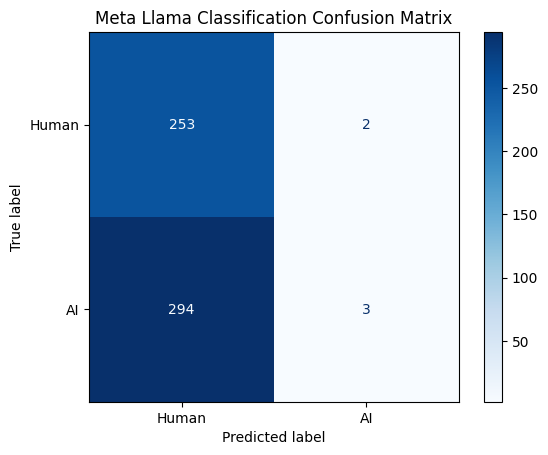

In [ ]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Human", "AI"]
)

disp.plot(cmap="Blues", values_format="d")  # values_format="d" shows integers
plt.title("Meta Llama Classification Confusion Matrix")
plt.show()

In [ ]:
accuracy_score(y_true_f, y_pred_f)

0.463768115942029

### To see the results from the remaining prompting techniques for the Llama model, refer to this table with confusion matrices and accuracy scores in the final report: https://docs.google.com/document/d/1XQgRs28iHyZEh8HGMXOTg7xntLy2mSInvu0sQS4imXU/edit?tab=t.0#bookmark=id.4p24k0z48vc3